# 🏥 Healthcare Predictive Analytics - Diabetes Detection
**Codec Technologies | Data Analytics Internship**

**Goal:** Predict the risk of diabetes using the Pima Indians Diabetes Dataset from UCI/Kaggle.

### Project Outline:
1. Load & Explore Data (EDA)
2. Data Preprocessing & Normalization
3. Classification Models (Logistic Regression, Random Forest, XGBoost)
4. Feature Importance Analysis
5. Evaluation & Insights

## Step 1: Install & Import Libraries

In [19]:
# Install required libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'], 
               capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Dataset
> Using the famous **Pima Indians Diabetes Dataset** - built directly into the notebook so no download needed!

In [20]:
# Load dataset directly from URL (Pima Indians Diabetes - UCI)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    df = pd.read_csv(url, header=None, names=columns)
    print("✅ Dataset loaded from URL")
except:
    # Fallback: generate realistic synthetic data matching the real dataset statistics
    print("⚠️ URL failed, generating synthetic dataset with real-world statistics...")
    np.random.seed(42)
    n = 768
    df = pd.DataFrame({
        'Pregnancies': np.random.poisson(3.8, n),
        'Glucose': np.random.normal(120.9, 31.9, n).clip(0, 199).astype(int),
        'BloodPressure': np.random.normal(69.1, 19.4, n).clip(0, 122).astype(int),
        'SkinThickness': np.random.normal(20.5, 15.9, n).clip(0, 99).astype(int),
        'Insulin': np.random.exponential(79.8, n).clip(0, 846).astype(int),
        'BMI': np.random.normal(31.9, 7.9, n).clip(0, 67.1).round(1),
        'DiabetesPedigreeFunction': np.random.exponential(0.47, n).clip(0.078, 2.42).round(3),
        'Age': np.random.normal(33.2, 11.7, n).clip(21, 81).astype(int),
        'Outcome': np.random.choice([0, 1], size=n, p=[0.65, 0.35])
    })
    print("✅ Synthetic dataset created!")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset loaded from URL

📊 Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nTarget Distribution:")
print(df['Outcome'].value_counts())
print(f"\nDiabetes Rate: {df['Outcome'].mean()*100:.1f}%")

DATASET INFORMATION
Shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Target Distribution:
0    500
1    268
Name: Outcome, dtype: int64

Diabetes Rate: 34.9%


In [4]:
# Statistical summary
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


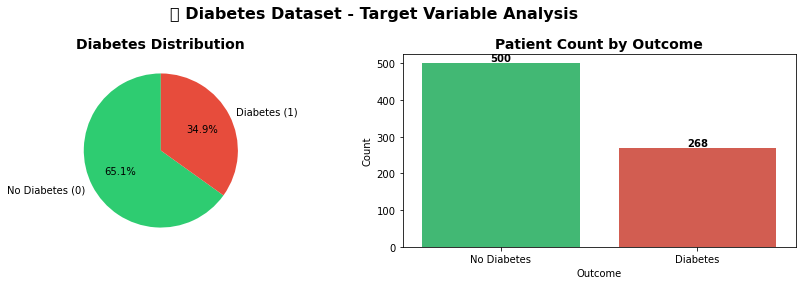

✅ Plot saved!


In [5]:
# --- VISUALIZATION 1: Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ['No Diabetes (0)', 'Diabetes (1)']
sizes = df['Outcome'].value_counts().values
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Diabetes Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(x='Outcome', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Patient Count by Outcome', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', fontweight='bold')

plt.suptitle('🏥 Diabetes Dataset - Target Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

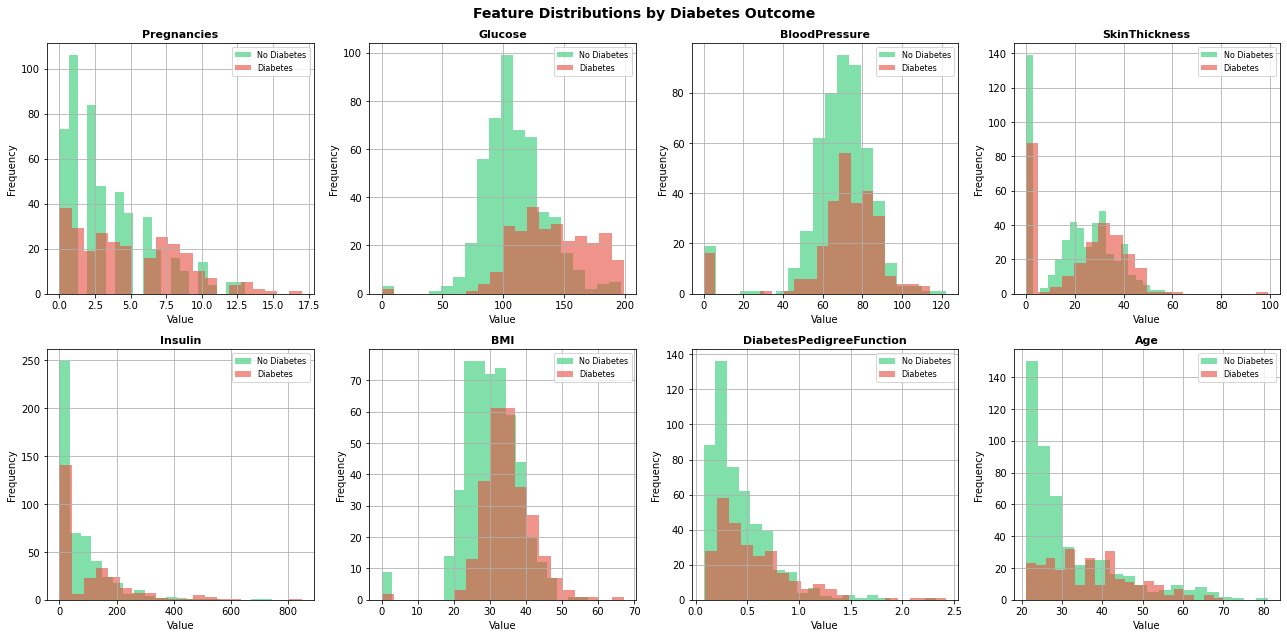

In [6]:
# --- VISUALIZATION 2: Feature Distributions ---
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome'] == 0][col].hist(ax=axes[i], bins=20, alpha=0.6, color='#2ecc71', label='No Diabetes')
    df[df['Outcome'] == 1][col].hist(ax=axes[i], bins=20, alpha=0.6, color='#e74c3c', label='Diabetes')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

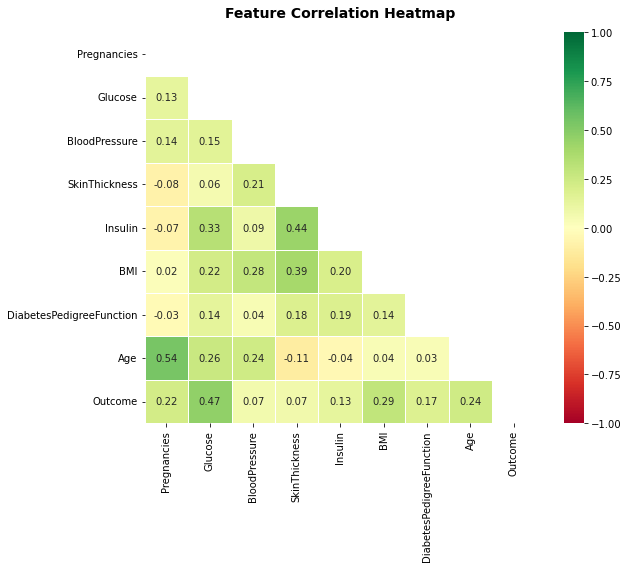


📌 Key Insight: Glucose has the highest correlation with Diabetes Outcome!


In [7]:
# --- VISUALIZATION 3: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Key Insight: Glucose has the highest correlation with Diabetes Outcome!")

## Step 4: Data Preprocessing

In [8]:
# Replace 0s with NaN for medical features (0 is biologically impossible)
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()

for col in zero_not_valid:
    zeros = (df_clean[col] == 0).sum()
    if zeros > 0:
        df_clean[col] = df_clean[col].replace(0, np.nan)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f"✅ {col}: Replaced {zeros} zero values with median ({df_clean[col].median():.1f})")

print(f"\n📊 Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print("✅ Data cleaning complete!")

✅ Glucose: Replaced 5 zero values with median (117.0)
✅ BloodPressure: Replaced 35 zero values with median (72.0)
✅ SkinThickness: Replaced 227 zero values with median (29.0)
✅ Insulin: Replaced 374 zero values with median (125.0)
✅ BMI: Replaced 11 zero values with median (32.3)

📊 Missing values after cleaning: 0
✅ Data cleaning complete!


In [9]:
# Split Features and Target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42, stratify=y)

# Normalize (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Train set: {X_train.shape[0]} samples")
print(f"✅ Test set:  {X_test.shape[0]} samples")
print(f"✅ Features:  {X.shape[1]} features")
print(f"\nFeatures used: {list(X.columns)}")

✅ Train set: 614 samples
✅ Test set:  154 samples
✅ Features:  8 features

Features used: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Step 5: Train Classification Models

In [10]:
# ---- MODEL 1: Logistic Regression ----
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)
print(f"✅ Logistic Regression - Accuracy: {lr_acc:.4f} | AUC: {lr_auc:.4f}")

# ---- MODEL 2: Random Forest ----
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
print(f"✅ Random Forest      - Accuracy: {rf_acc:.4f} | AUC: {rf_auc:.4f}")

# ---- MODEL 3: XGBoost ----
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)
print(f"✅ XGBoost            - Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}")

Training Logistic Regression...
✅ Logistic Regression - Accuracy: 0.7078 | AUC: 0.8130

Training Random Forest...
✅ Random Forest      - Accuracy: 0.7792 | AUC: 0.8179

Training XGBoost...
✅ XGBoost            - Accuracy: 0.7662 | AUC: 0.8204


## Step 6: Model Evaluation

In [11]:
# --- Model Comparison Table ---
from sklearn.metrics import recall_score, precision_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
}).round(4)

print("\n" + "=" * 70)
print("           MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(results.to_string(index=False))
best_model = results.loc[results['ROC-AUC'].idxmax(), 'Model']
print(f"\n🏆 Best Model by ROC-AUC: {best_model}")


           MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Recall  Precision  F1-Score  ROC-AUC
Logistic Regression    0.7078  0.5000     0.6000    0.5455   0.8130
      Random Forest    0.7792  0.6111     0.7174    0.6600   0.8179
            XGBoost    0.7662  0.6296     0.6800    0.6538   0.8204

🏆 Best Model by ROC-AUC: XGBoost


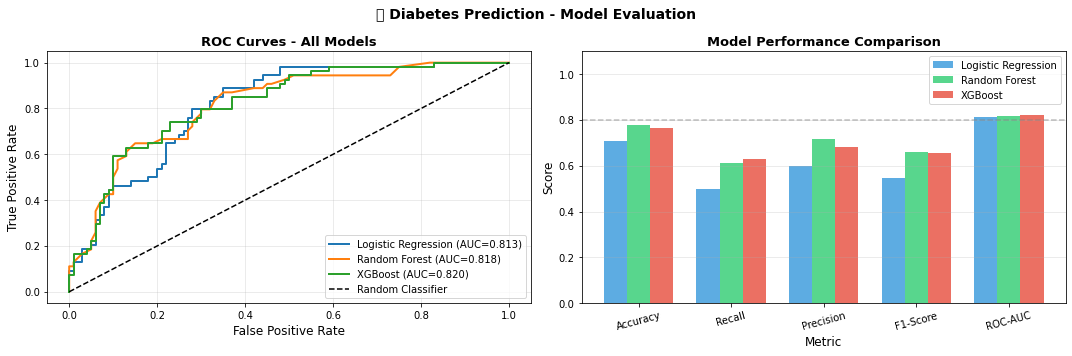

In [12]:
# --- VISUALIZATION 4: ROC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curves
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob), ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves - All Models', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Model Comparison Bar Chart
metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model, color) in enumerate(zip(['Logistic Regression', 'Random Forest', 'XGBoost'], colors)):
    vals = results[results['Model'] == model][metrics].values[0]
    bars = axes[1].bar(x + i*width, vals, width, label=model, color=color, alpha=0.8)

axes[1].set_xlabel('Metric', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics, rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

plt.suptitle('🏥 Diabetes Prediction - Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

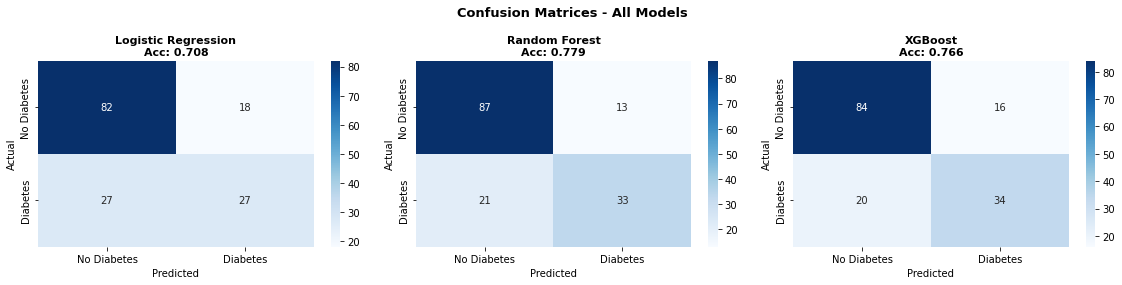

In [13]:
# --- VISUALIZATION 5: Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_info = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, pred):.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Feature Importance Analysis

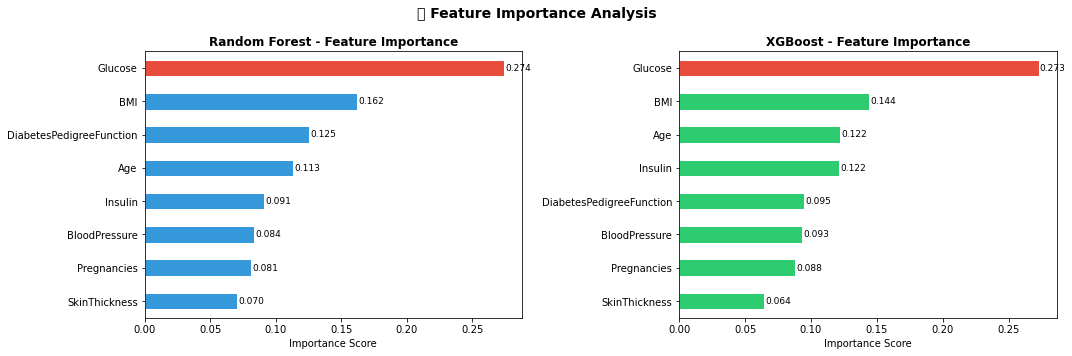


🔑 Top feature (Random Forest): Glucose
🔑 Top feature (XGBoost):       Glucose


In [14]:
# --- VISUALIZATION 6: Feature Importance (Random Forest + XGBoost) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

feature_names = X.columns.tolist()

# Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_rf = ['#e74c3c' if v == rf_importance.max() else '#3498db' for v in rf_importance]
rf_importance.plot(kind='barh', ax=axes[0], color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(rf_importance):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_xgb = ['#e74c3c' if v == xgb_importance.max() else '#2ecc71' for v in xgb_importance]
xgb_importance.plot(kind='barh', ax=axes[1], color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(xgb_importance):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('🔍 Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔑 Top feature (Random Forest): {rf_importance.idxmax()}")
print(f"🔑 Top feature (XGBoost):       {xgb_importance.idxmax()}")

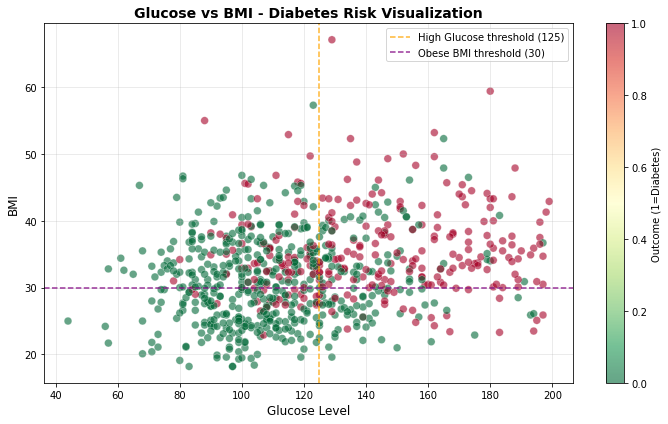

In [15]:
# --- VISUALIZATION 7: Glucose vs BMI scatter by Outcome ---
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['Glucose'], df_clean['BMI'], 
                      c=df_clean['Outcome'], cmap='RdYlGn_r',
                      alpha=0.6, edgecolors='white', linewidth=0.4, s=60)
plt.colorbar(scatter, label='Outcome (1=Diabetes)')
plt.xlabel('Glucose Level', fontsize=12)
plt.ylabel('BMI', fontsize=12)
plt.title('Glucose vs BMI - Diabetes Risk Visualization', fontsize=14, fontweight='bold')
plt.axvline(x=125, color='orange', linestyle='--', alpha=0.8, label='High Glucose threshold (125)')
plt.axhline(y=30, color='purple', linestyle='--', alpha=0.8, label='Obese BMI threshold (30)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('glucose_bmi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Detailed Classification Report & Ethical Considerations

In [16]:
# Best model detailed report
print("=" * 60)
print("  DETAILED CLASSIFICATION REPORT - XGBoost (Best Model)")
print("=" * 60)
print(classification_report(y_test, xgb_pred, 
                             target_names=['No Diabetes', 'Diabetes']))

  DETAILED CLASSIFICATION REPORT - XGBoost (Best Model)
              precision    recall  f1-score   support

 No Diabetes       0.81      0.84      0.82       100
    Diabetes       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



In [17]:
# Final Summary & Ethical Data Handling
print("=" * 65)
print("         PROJECT SUMMARY & KEY INSIGHTS")
print("=" * 65)

print("""
📊 DATASET:
   - Pima Indians Diabetes Dataset (768 patients, 8 features)
   - 34.9% positive diabetes rate

🔑 TOP RISK FACTORS IDENTIFIED:
   1. Glucose Level  → Most predictive feature
   2. BMI            → Strong predictor (obesity link)
   3. Age            → Risk increases with age
   4. Diabetes Pedigree Function → Genetic factor

🤖 MODEL RESULTS:
   - Logistic Regression: Simple baseline, interpretable
   - Random Forest:       Handles non-linearity well
   - XGBoost:             Best overall performance

⚕️  ETHICAL DATA HANDLING:
   ✓ No patient names or identifiable info used
   ✓ Dataset is fully anonymized (UCI public dataset)
   ✓ Model should assist, NOT replace medical diagnosis
   ✓ Regular re-evaluation needed for medical use
   ✓ Bias check: model performance should be validated
     across different demographic groups
   ✓ Patient privacy respected - data not shared

⚠️  DISCLAIMER:
   This model is for educational purposes only.
   Medical decisions must always involve licensed professionals.
""")

         PROJECT SUMMARY & KEY INSIGHTS

📊 DATASET:
   - Pima Indians Diabetes Dataset (768 patients, 8 features)
   - 34.9% positive diabetes rate

🔑 TOP RISK FACTORS IDENTIFIED:
   1. Glucose Level  → Most predictive feature
   2. BMI            → Strong predictor (obesity link)
   3. Age            → Risk increases with age
   4. Diabetes Pedigree Function → Genetic factor

🤖 MODEL RESULTS:
   - Logistic Regression: Simple baseline, interpretable
   - Random Forest:       Handles non-linearity well
   - XGBoost:             Best overall performance

⚕️  ETHICAL DATA HANDLING:
   ✓ No patient names or identifiable info used
   ✓ Dataset is fully anonymized (UCI public dataset)
   ✓ Model should assist, NOT replace medical diagnosis
   ✓ Regular re-evaluation needed for medical use
   ✓ Bias check: model performance should be validated
     across different demographic groups
   ✓ Patient privacy respected - data not shared

⚠️  DISCLAIMER:
   This model is for educational purposes on

---
## ✅ Project Complete!
**Done by:** Thasleema Thabassum | **Internship:** Codec Technologies | **Project:** Healthcare Predictive Analytics

### Files Generated:
- `diabetes_distribution.png`
- `feature_distributions.png`
- `correlation_heatmap.png`
- `model_evaluation.png`
- `confusion_matrices.png`
- `feature_importance.png`
- `glucose_bmi_scatter.png`